In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import Axes3D
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Añadir ruta local si es necesario (ajustar según tu estructura)
sys.path.append(r'c:/Users/sebas/MalariaProject/')

from src import *

# Configuración de estilo para plots
#plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['font.size'] = 11

print("✅ Módulos importados correctamente")

✅ Módulos importados correctamente


In [3]:
archivo = "beta-hematina.txt"

data_txt = pd.read_csv(archivo, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

#times = np.linspace(0, 300, 20)
times_txt = np.array(data_txt['Tiempo'])
all_times = np.array(list(set(times_txt/5) | set(times_txt/4) | set(times_txt/2) | set(times_txt)))

times = times_txt

In [89]:
times = np.arange(0, 200, 1)

In [90]:
sigmas = np.linspace(0.5, 8, 6)

In [27]:
sigmas

array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5,
       7. , 7.5, 8. ])

In [ ]:
#sigmas = np.arange(1, 8.5, 0.5)
#times = np.linspace(0, 8, 100)

In [91]:
def compute_probabilities(sigmas, times, delta, size=(75, 75), mode="flat", n_seeds=1025):

    prob_sta = []
    kmcs = []
    snaps_list = []

    # L = LatticeSOS_v2(size=size, seed=42)
    # # L.initialize(mode="random", max_height=1, n_seeds=1905)
    # L.initialize(mode=mode)

    for sigma in sigmas:
        print(f"\n\n=== σ = {sigma} ===")

        L = LatticeSOS_v2(size=size, seed=42+int(sigma))
        # L.initialize(mode="random", max_height=1, n_seeds=1905)
        L.initialize(mode=mode, max_height=0, n_seeds=n_seeds)

        params = KMCParams_v2(
        K0_plus= 0.2116718, #0.211,
        E_pb_over_kT= 1.2704636027368605, #.48,
        phi_over_kT= 1.3792478012079329, #3.76,
        delta=delta,
        V=1,
        C_eq=15.0,
        fixed_sigma=sigma,   # usa un valor como 3.0 si quieres sigma estático
        S_floor=-5.0,
        S_ceil=9.0,
        )

        kmc = KMC_BKL_v2(
            lattice=L,
            params=params,
            N_bulk0=2000,
            rng_seed=123,
            time_scale=100,
            n_seeds=n_seeds,
            constant_concentration=True,  # batch dinámico
        )
        kmcs.append(kmc)

        snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)
        snaps_list.append(snaps)

        prob_sta.append(stats['adsorption_probs_history'])

        print(f"Datos para σ = {sigma} guardados.\n")

    return prob_sta, kmcs, snaps_list

In [86]:
# ============================================
# Extraer p0, p1, p2 desde prob_sta
# ============================================

def extraer_probs_desde_prob_sta(prob_sta):
    # Devuelve probabilidades promedio en la cola temporal para cada sigma
    p0, p1, p2 = [], [], []
    sigmas_plot = []

    for hist in prob_sta:
        # Si no hay historial para ese sigma, guardar NaN
        if len(hist) == 0:
            p0.append(np.nan); p1.append(np.nan); p2.append(np.nan); sigmas_plot.append(np.nan)
            continue

        # Sigma asociado a esa corrida (constante en esa historia)
        sigmas_plot.append(float(hist[-1][1]))

        # Tomar la cola temporal para aproximar estado cuasi-estacionario
        #n = len(hist)
        #k0 = max(0, int((1.0 - frac_tail) * n))
        tail = hist[:]

        vals0, vals1, vals2 = [], [], []
        for _, _, probs in tail:
            vals0.append(float(probs.get(0, 0.0)))
            vals1.append(float(probs.get(1, 0.0)))
            vals2.append(float(probs.get(2, 0.0)))

        # Promedio por sigma
        p0.append(np.mean(vals0) if len(vals0) else np.nan)
        p1.append(np.mean(vals1) if len(vals1) else np.nan)
        p2.append(np.mean(vals2) if len(vals2) else np.nan)

    return np.array(sigmas_plot), np.array(p0), np.array(p1), np.array(p2)

In [87]:
def plot_probs_vs_sigma(sigmas_plot, p0, p1, p2, path=None):
    # Ordenar por sigma por seguridad (por si llegan desordenados)
    idx = np.argsort(sigmas_plot)
    sigmas_plot = sigmas_plot[idx]
    p0 = p0[idx]
    p1 = p1[idx]
    p2 = p2[idx]

    # ============================================
    # Gráfica
    # ============================================
    fig, ax = plt.subplots()
    plt.gca().set_facecolor("#e9e9e9")

    # Regiones de régimen
    # ax.axvspan(1.0, 2.5, alpha=0.1, color='gold')
    # ax.axvspan(2.5, 6.0, alpha=0.1, color='orange')
    # ax.axvspan(6.0, 8.0, alpha=0.1, color='green')

    # ax.text(1.8, 0.52, 'SPIRAL', fontsize=11, ha='center', fontweight='bold', color='darkgoldenrod')
    # ax.text(4.25, 0.52, 'STEP', fontsize=11, ha='center', fontweight='bold', color='darkorange')
    # ax.text(7.0, 0.52, 'ROUGH', fontsize=11, ha='center', fontweight='bold', color='darkgreen')

    # Curvas de probabilidad extraídas desde prob_sta
    plt.plot(sigmas_plot, p0, color="#0072BD", linewidth=2.5, label='i=0 (adatom)')
    plt.plot(sigmas_plot, p1, color="#D95319", linewidth=2.5, label='i=1 (step)')
    plt.plot(sigmas_plot, p2, color="#EDB120", linewidth=2.5, label='i=2 (kink)')

    plt.xlim(1, 8)
    plt.xlabel("Sobresaturación (σ)")
    plt.ylabel("Probabilidad")
    plt.title("Probabilidades por sitio de adsorción")
    plt.legend()

    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True
    )
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    plt.grid(False)
    if path:
        plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()



=== σ = 0.5 ===
Datos para σ = 0.5 guardados.



=== σ = 2.0 ===
Datos para σ = 2.0 guardados.



=== σ = 3.5 ===
Datos para σ = 3.5 guardados.



=== σ = 5.0 ===
Datos para σ = 5.0 guardados.



=== σ = 6.5 ===
Datos para σ = 6.5 guardados.



=== σ = 8.0 ===
Datos para σ = 8.0 guardados.



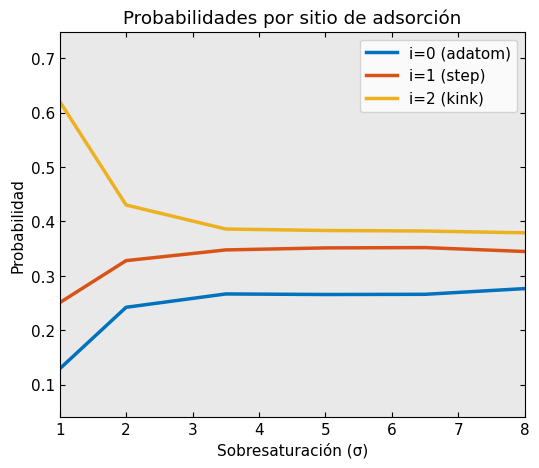

In [92]:
prob_sta, kmcs, snaps_list = compute_probabilities(sigmas, times, delta=1., size=(35, 35), mode="flat", n_seeds=625)
sigmas_plot, p0, p1, p2 = extraer_probs_desde_prob_sta(prob_sta)
plot_probs_vs_sigma(sigmas_plot, p0, p1, p2, path="adsorption_probabilities_vs_sigma.png")

In [30]:
kmcs

In [98]:
plotter = Plotter_v2(kmcs[25])

🧩 Snapshot seleccionado: t=18.000
💾 Imagen guardada en: crystal_growth.png


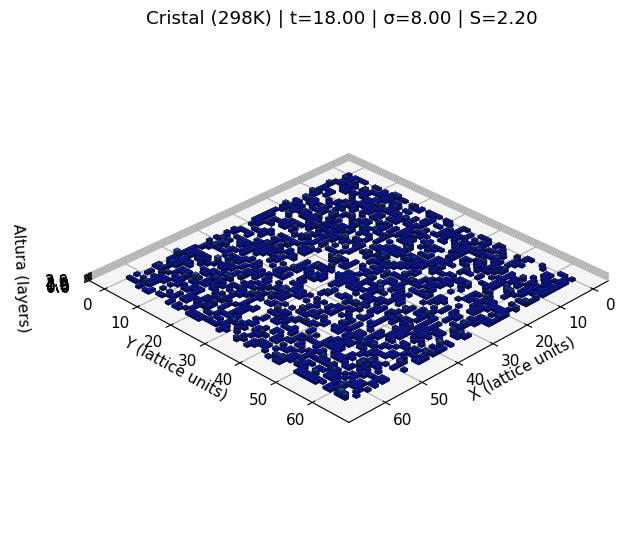

In [99]:
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_list[25],
    t_snapshot=times[len(times)- 7],
    save_path="crystal_growth.png",
)

In [100]:
plotter.crystal_growth_gif(
    snapshots=snaps_list[25],
    save_path="crystal_growth_25.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_25.gif


In [78]:
times = np.arange(0, 200, 1)

L = LatticeSOS_v2(size=(35, 35), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L.initialize(mode="flat", max_height=0)

params = KMCParams_v2(
K0_plus= 0.2116718, #0.211,
E_pb_over_kT= 1.2704636027368605, #.48,
phi_over_kT= 1.3792478012079329, #3.76,
delta=2,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc = KMC_BKL_v2(
    lattice=L,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=80,
    n_seeds=1224,
    constant_concentration=True,  # batch dinámico
)

In [79]:
snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)

🧩 Snapshot seleccionado: t=199.000
💾 Imagen guardada en: crystal_growth_prueba.png


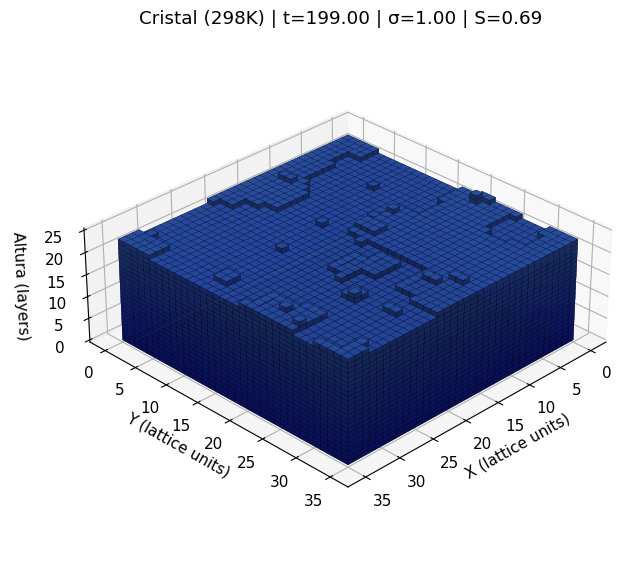

In [80]:
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba.png",
)

In [81]:
plotter.crystal_growth_gif(
    snapshots=snaps,
    save_path="crystal_growth_prueba.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_prueba.gif


In [20]:
35*35

1225